In [1]:
import sys
print(sys.executable)
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

/Users/mac/Desktop/Readmission-risk-predictor/venv/bin/python


In [2]:
import pandas as pd
from src.config import RAW_DATA_DIR

df = pd.read_csv(RAW_DATA_DIR / "diabetes130us_openml.csv")

df.shape

(101766, 50)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   encounter_id              101766 non-null  float64
 1   patient_nbr               101766 non-null  float64
 2   race                      101766 non-null  str    
 3   gender                    101766 non-null  str    
 4   age                       101766 non-null  str    
 5   weight                    101766 non-null  str    
 6   admission_type_id         101766 non-null  int64  
 7   discharge_disposition_id  101766 non-null  int64  
 8   admission_source_id       101766 non-null  int64  
 9   time_in_hospital          101766 non-null  int64  
 10  payer_code                101766 non-null  str    
 11  medical_specialty         101766 non-null  str    
 12  num_lab_procedures        101766 non-null  int64  
 13  num_procedures            101766 non-null  int64  
 14 

In [4]:
df.replace("?", pd.NA, inplace = True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,2278392.0,8222157.0,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190.0,55629189.0,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410.0,86047875.0,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364.0,82442376.0,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680.0,42519267.0,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548.0,100162476.0,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782.0,74694222.0,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148.0,41088789.0,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166.0,31693671.0,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [5]:
target = "readmitted"

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

if target in cat_cols:
    cat_cols.remove(target)

print("Numerical features:", len(num_cols))
print(num_cols)

print("\nCategorical features:", len(cat_cols))
print(cat_cols)


Numerical features: 13
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features: 36
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide.metformin', 'glipizide.metformin', 'glimepiride.pioglitazone', 'metformin.rosiglitazone', 'metformin.pioglitazone', 'change', 'diabetesMed']


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [7]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent[missing_percent>0].sort_values(ascending=False)

missing_percent

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

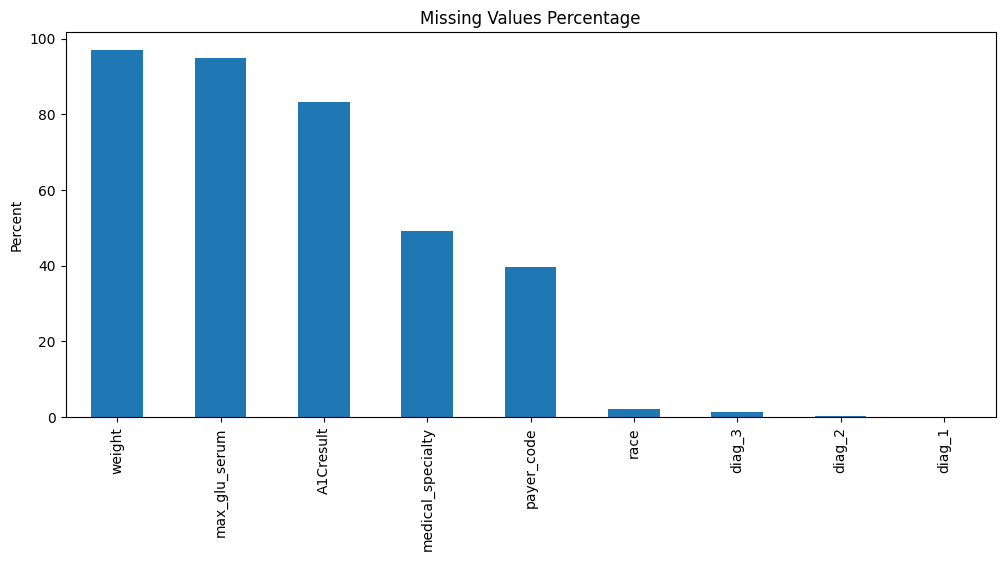

In [8]:
import matplotlib.pyplot as plt

missing_percent.plot(kind="bar", figsize=(12,5))
plt.title("Missing Values Percentage")
plt.ylabel("Percent")
plt.show()

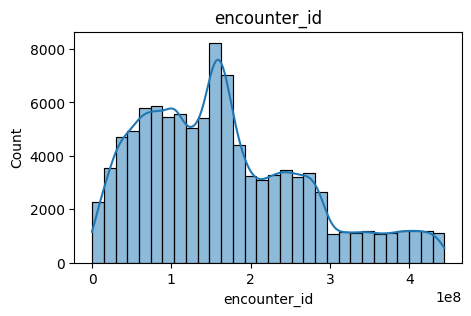

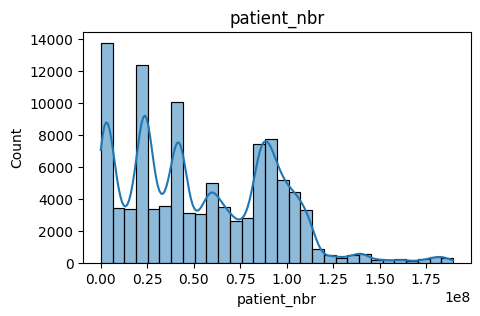

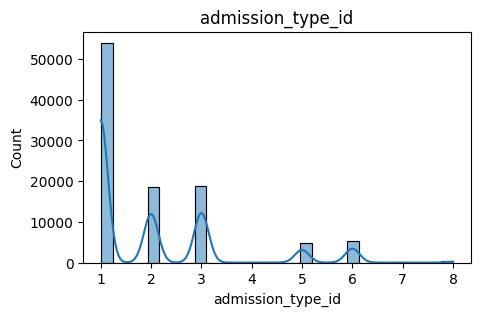

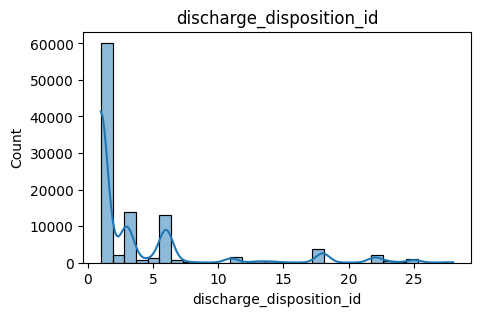

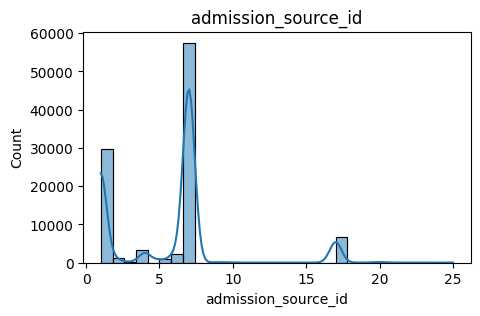

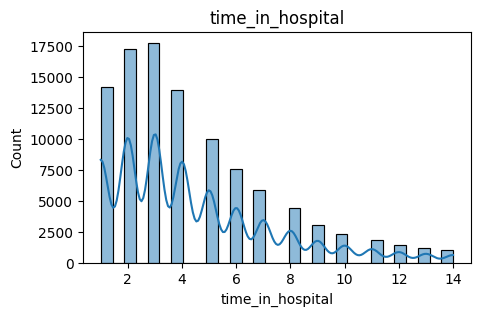

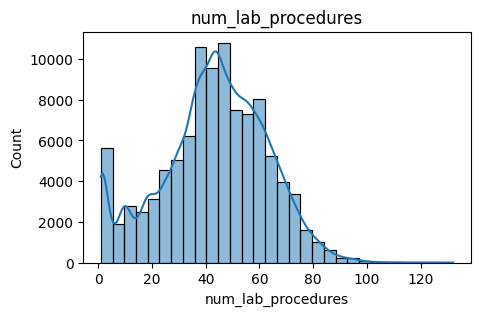

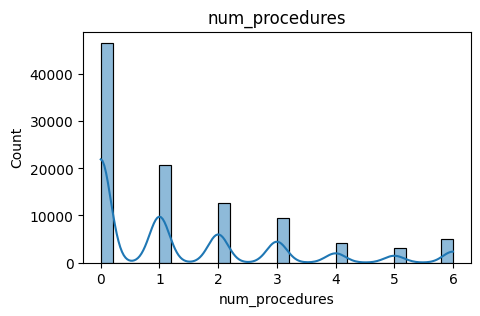

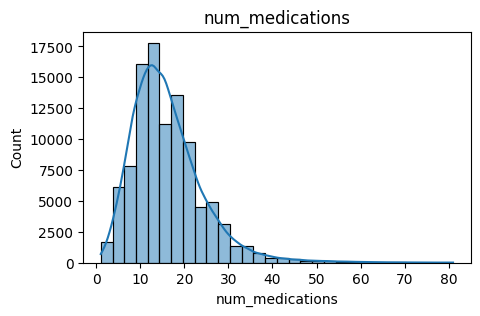

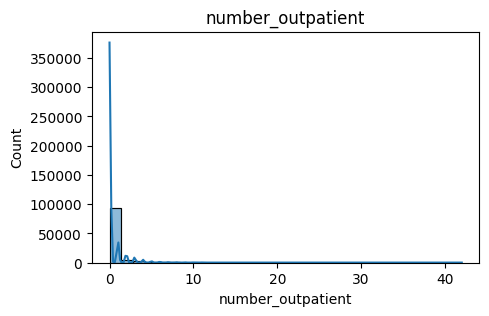

In [9]:
import seaborn as sns 

for col in num_cols[:10]: #First 10
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

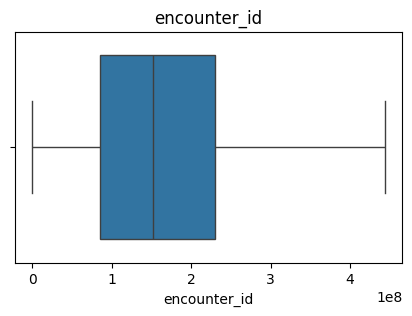

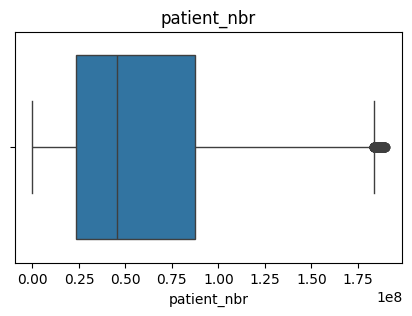

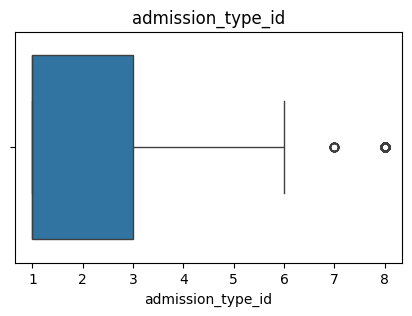

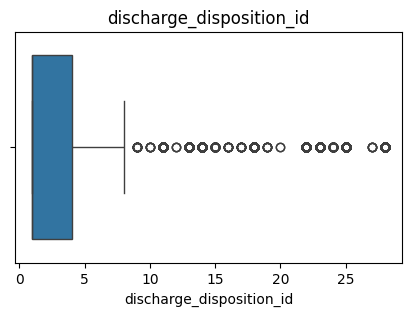

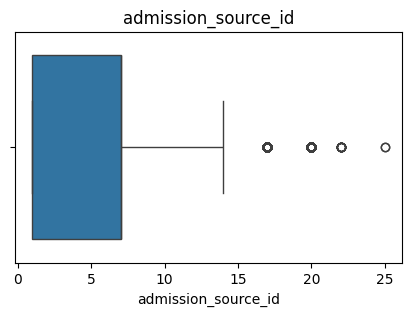

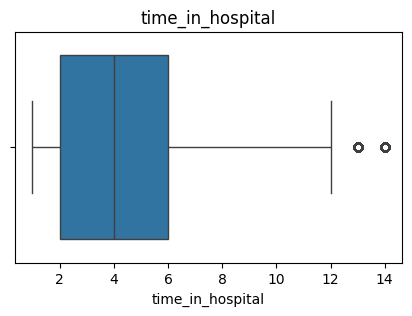

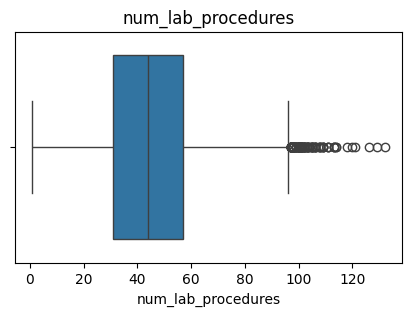

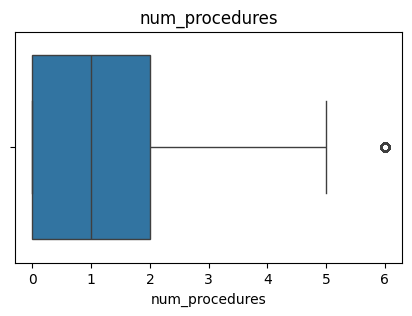

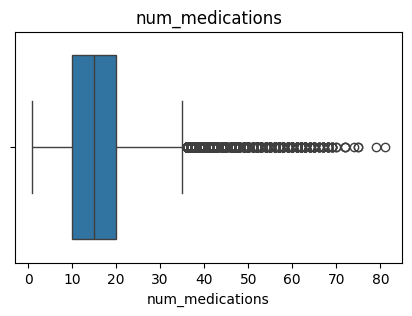

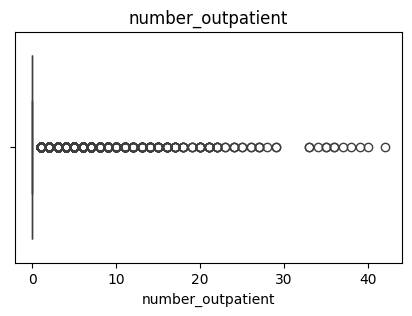

In [10]:
for col in num_cols[:10]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

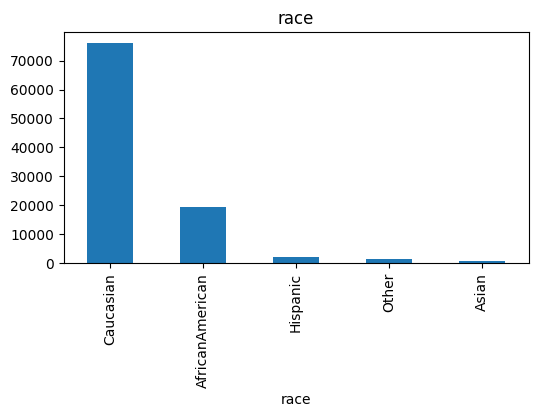

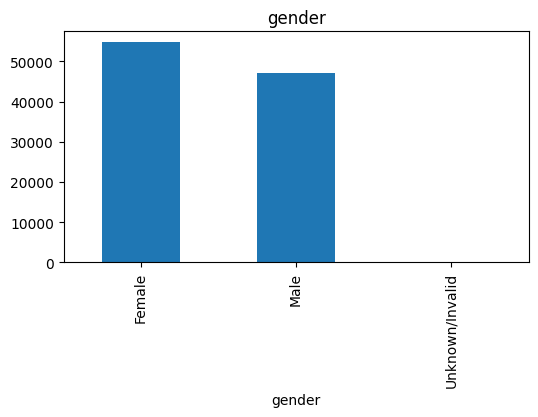

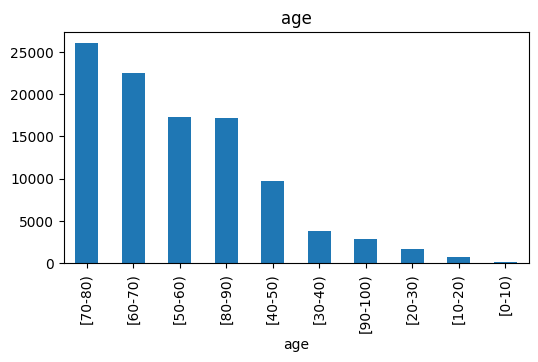

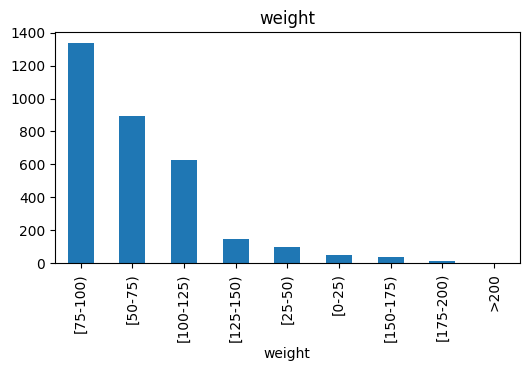

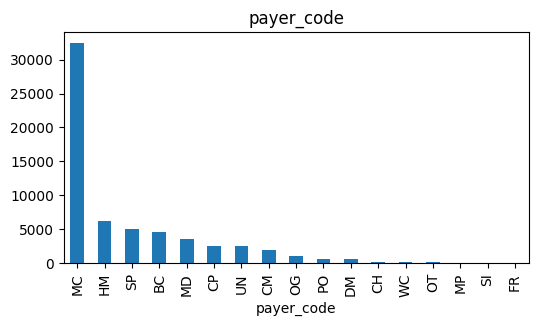

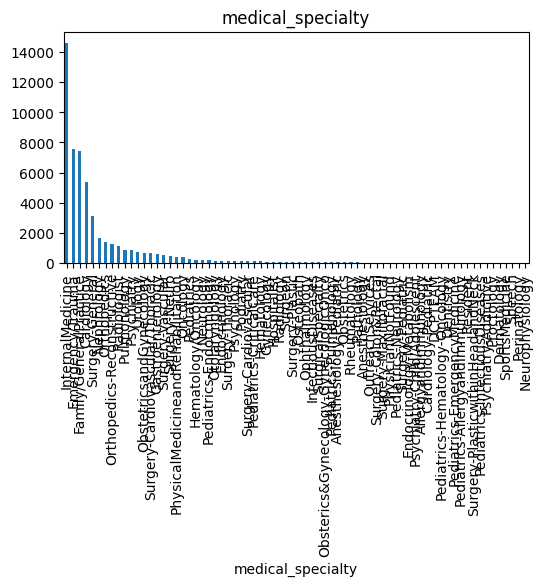

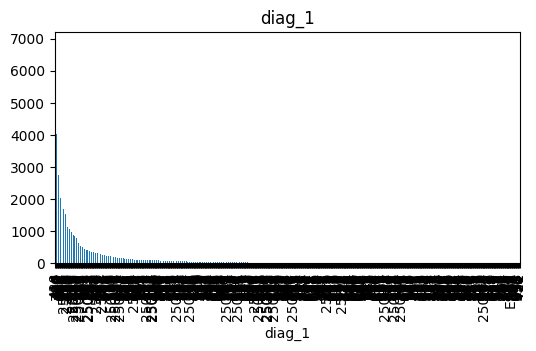

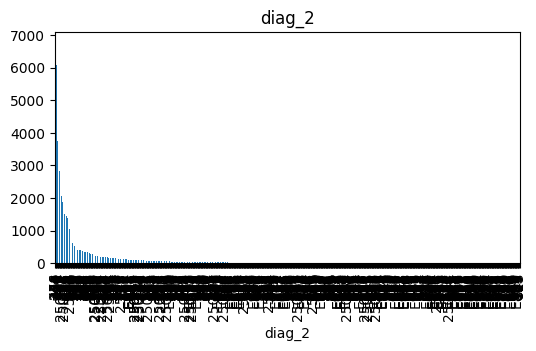

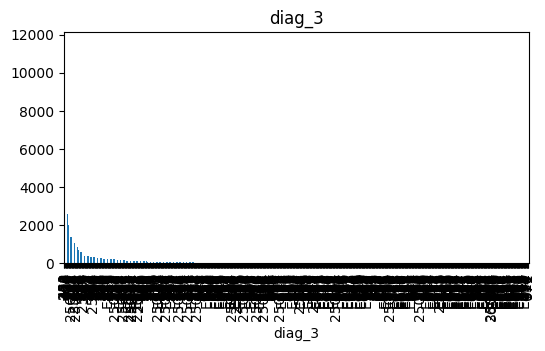

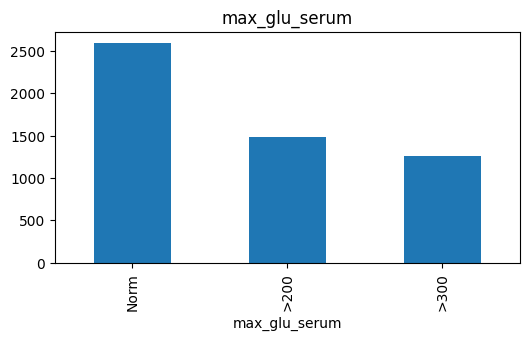

In [11]:
for col in cat_cols[:10]:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

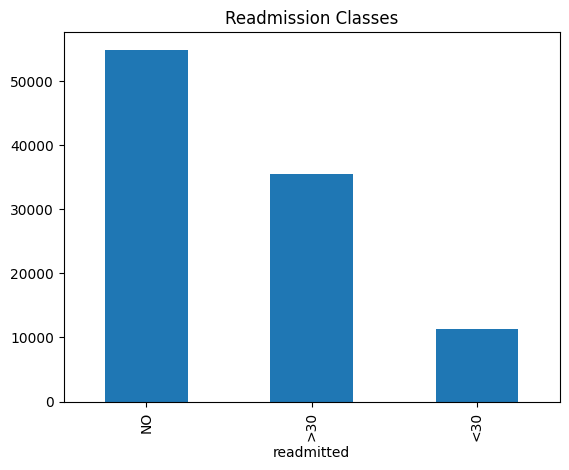

In [12]:
df['readmitted'].value_counts().plot(kind="bar")
plt.title("Readmission Classes")
plt.show()

In [13]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

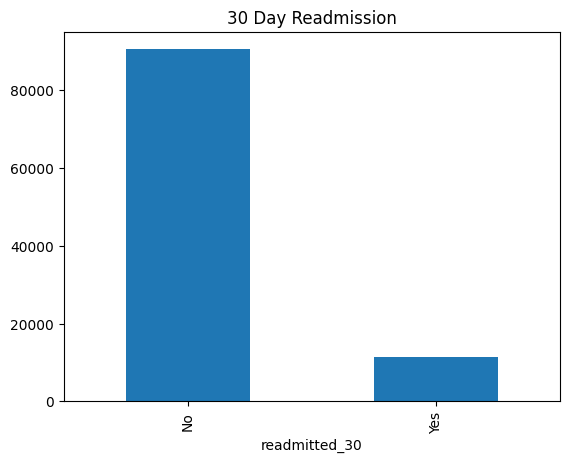

In [14]:
df["readmitted_30"].value_counts().plot(kind="bar")
plt.title("30 Day Readmission")
plt.xticks([0,1], ["No", "Yes"])
plt.show()